# Logistic Regression on E-commerce Customer Churn

Implementation of binary classification using logistic regression from scratch:
- Sigmoid function
- Binary cross-entropy loss
- Gradient descent

Target: predict whether a customer will churn (`churned = 1`) or not (`churned = 0`).  
Only numerical features are used — categorical handling comes later.

## Dataset
E-commerce customer behavior dataset from Kaggle: [E-Commerce Customer Behavior and Sales 2020–2026](https://www.kaggle.com/datasets/meruvakodandasuraj/e-commerce-customer-behavior-and-sales-20202026).  
8,000 customers with purchase history, engagement metrics, and demographics.  
Features used: `age`, `total_orders`, `total_spend_usd`, `avg_order_value_usd`,
`days_since_last_purchase`, `reviews_given`, `avg_review_score`, `returns_made`,
`wishlist_items`, `newsletter_subscribed`.

### Imports

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [12]:
df = pd.read_csv("data/customers.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (8000, 20)


,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,2019-01-17,4,286.63,63.78,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.5,0,12,0,0
1,C00002,United States,20,Female,Free,2026-03-04,11,1245.18,107.32,126,Toys & Games,Mobile,Debit Card,Organic Search,2,2.6,1,1,0,0
2,C00003,United States,43,Female,Gold,2026-02-08,4,195.37,42.74,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.8,0,0,1,0
3,C00004,United States,41,Male,Free,2025-03-19,6,99.45,15.61,6,Electronics,Desktop,PayPal,Organic Search,2,4.2,0,8,1,0
4,C00005,France,37,Other,Platinum,2024-09-10,36,2593.21,79.09,161,Clothing & Apparel,Tablet,Debit Card,Social Media,9,4.0,4,5,1,0


### Exploration

In [13]:
df.isnull().sum()

customer_id                 0
country                     0
age                         0
gender                      0
membership_tier             0
registration_date           0
total_orders                0
total_spend_usd             0
avg_order_value_usd         0
days_since_last_purchase    0
preferred_category          0
preferred_device            0
preferred_payment_method    0
acquisition_channel         0
reviews_given               0
avg_review_score            0
returns_made                0
wishlist_items              0
newsletter_subscribed       0
churned                     0
dtype: int64

Not churned (0): 7,285 (91.1%)
Churned     (1): 715 (8.9%)


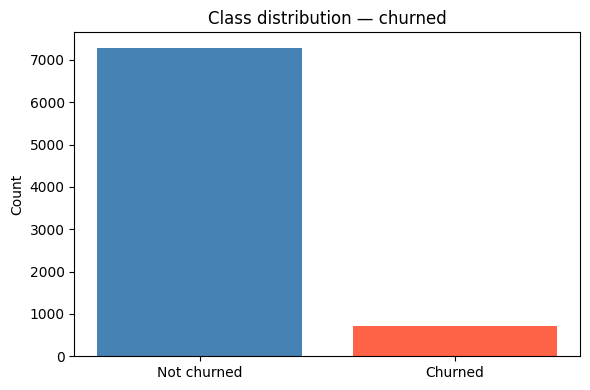

In [14]:
churn_counts = df["churned"].value_counts()
print(f"Not churned (0): {churn_counts[0]:,} ({churn_counts[0]/len(df)*100:.1f}%)")
print(f"Churned     (1): {churn_counts[1]:,} ({churn_counts[1]/len(df)*100:.1f}%)")

plt.figure(figsize=(6, 4))
plt.bar(["Not churned", "Churned"], churn_counts.values, color=["steelblue", "tomato"])
plt.title("Class distribution — churned")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [15]:
feature_cols = [
    "age", "total_orders", "total_spend_usd", "avg_order_value_usd",
    "days_since_last_purchase", "reviews_given", "avg_review_score",
    "returns_made", "wishlist_items", "newsletter_subscribed"
]

df[feature_cols + ["churned"]].describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,16.545250,1558.642350,94.845566,59.583875,3.228750,4.109112,0.849500,4.457125,0.617375,0.089375
std,11.170455,14.681064,2284.094953,78.992885,60.610355,3.942698,0.523992,1.407337,4.854391,0.486058,0.285302
min,18.000000,1.000000,4.890000,5.000000,0.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,5.000000,336.055000,44.690000,16.000000,0.000000,3.800000,0.000000,1.000000,0.000000,0.000000
50%,35.000000,12.000000,845.700000,72.270000,41.000000,2.000000,4.200000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,23.000000,1892.165000,118.560000,84.000000,5.000000,4.500000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,1051.730000,582.000000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


### Extract features and target

In [16]:
X = df[feature_cols].values.astype(float)
y = df["churned"].values.astype(float)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (8000, 10)
y shape: (8000,)


### Normalize features

We z-score normalize X so all features are on the same scale, without this, features like
`total_spend_usd` (thousands) would dominate over `reviews_given` (single digits) and 
gradient descent would converge much slower.

We do **not** normalize y: it's already binary (0/1), exactly the range the sigmoid outputs.

In [17]:
mu_X    = X.mean(axis=0)
sigma_X = X.std(axis=0)

X_norm = (X - mu_X) / sigma_X

print("Feature means:")
for name, mu in zip(feature_cols, mu_X):
    print(f"  {name:<30} {mu:.4f}")

print("\nFeature stds:")
for name, sigma in zip(feature_cols, sigma_X):
    print(f"  {name:<30} {sigma:.4f}")

Feature means:
  age                            35.6164
  total_orders                   16.5452
  total_spend_usd                1558.6424
  avg_order_value_usd            94.8456
  days_since_last_purchase       59.5839
  reviews_given                  3.2287
  avg_review_score               4.1091
  returns_made                   0.8495
  wishlist_items                 4.4571
  newsletter_subscribed          0.6174

Feature stds:
  age                            11.1698
  total_orders                   14.6801
  total_spend_usd                2283.9522
  avg_order_value_usd            78.9879
  days_since_last_purchase       60.6066
  reviews_given                  3.9425
  avg_review_score               0.5240
  returns_made                   1.4072
  wishlist_items                 4.8541
  newsletter_subscribed          0.4860


### Add bias term (column of ones)

$$h_\theta(x) = \sigma(\theta_0 + \theta_1 x_1 + \dots + \theta_n x_n) = \sigma(\theta^T x)$$

Adding a column of ones lets $\theta_0$ be learned as part of the matrix operation $X\theta$,
without special-casing the intercept.

In [18]:
X_b = np.column_stack([np.ones(len(X_norm)), X_norm])

print(f"X_b shape: {X_b.shape}")
print(f"\nFirst 3 rows of X_b:")
print(X_b[:3])

X_b shape: (8000, 11)

First 3 rows of X_b:
[[ 1.          0.39245485 -0.85457253 -0.55693475 -0.39329501 -0.17463248
  -0.56532085  0.74602664 -0.60366005  1.55392246 -1.27024604]
 [ 1.         -1.39809451 -0.37773805 -0.13724558  0.15792832  1.09585691
  -0.31167156 -2.88021011  0.10694625 -0.7122091  -1.27024604]
 [ 1.          0.66103725 -0.85457253 -0.59689181 -0.65966476 -0.98312572
  -0.81897014  1.31859034 -0.60366005 -0.91822106  0.78724906]]


### Train/Test Split

80/20 split — same convention as the linear regression notebooks.

In [19]:
np.random.seed(42)
m = len(X_b)
indices = np.random.permutation(m)

train_size = int(0.8 * m)
train_idx  = indices[:train_size]
test_idx   = indices[train_size:]

X_train, X_test = X_b[train_idx], X_b[test_idx]
y_train, y_test = y[train_idx],   y[test_idx]

print(f"Train size: {len(X_train):,}")
print(f"Test size:  {len(X_test):,}")

Train size: 6,400
Test size:  1,600


## Sigmoid

The sigmoid squashes any real number into $(0, 1)$, which we interpret as the probability 
that $y = 1$:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

$$h_\theta(x) = \sigma(\theta^T x) = P(y=1 \mid x; \theta)$$

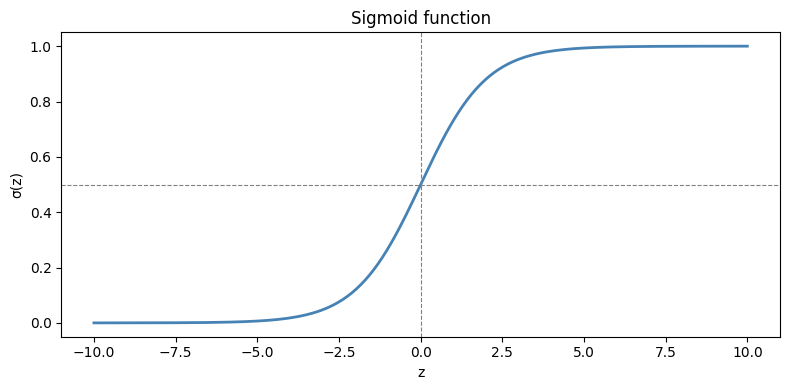

In [20]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 300)

plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), color="steelblue", linewidth=2)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0,   color="gray", linestyle="--", linewidth=0.8)
plt.title("Sigmoid function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.tight_layout()
plt.show()

## Loss and Cost

**Loss**: binary cross-entropy for a single example:

$$\mathcal{L}(\hat{y}, y) = -\left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]$$

**Cost**: average loss over all training examples:

$$J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}(h_\theta(x^{(i)}), y^{(i)})$$

In [21]:
def binary_cross_entropy(y_hat, y):
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def cost_function(X, y, theta):
    m = len(y)
    y_hat = sigmoid(X @ theta)
    return np.mean(binary_cross_entropy(y_hat, y))

## Gradient Descent

The gradient of $J(\theta)$ with respect to $\theta$ is:

$$\frac{\partial J}{\partial \theta} = \frac{1}{m} X^T (h_\theta(X) - y)$$

Surprisingly, the same form as linear regression — the difference is that here 
$h_\theta(X) = \sigma(X\theta)$ instead of $X\theta$.

Update rule:

$$\theta := \theta - \alpha \frac{\partial J}{\partial \theta}$$

In [28]:
def gradient_descent(X, y, alpha, n_iterations):
    m = len(y)
    theta = np.zeros(X.shape[1])
    cost_history  = []
    theta_history = [theta.copy()]

    for _ in range(n_iterations):
        y_hat    = sigmoid(X @ theta)
        gradient = (1 / m) * X.T @ (y_hat - y)
        theta    = theta - alpha * gradient
        cost_history.append(cost_function(X, y, theta))
        theta_history.append(theta.copy())

    return theta, cost_history, theta_history

## Training

Grid search over learning rates and iterations to find the best hyperparameters.

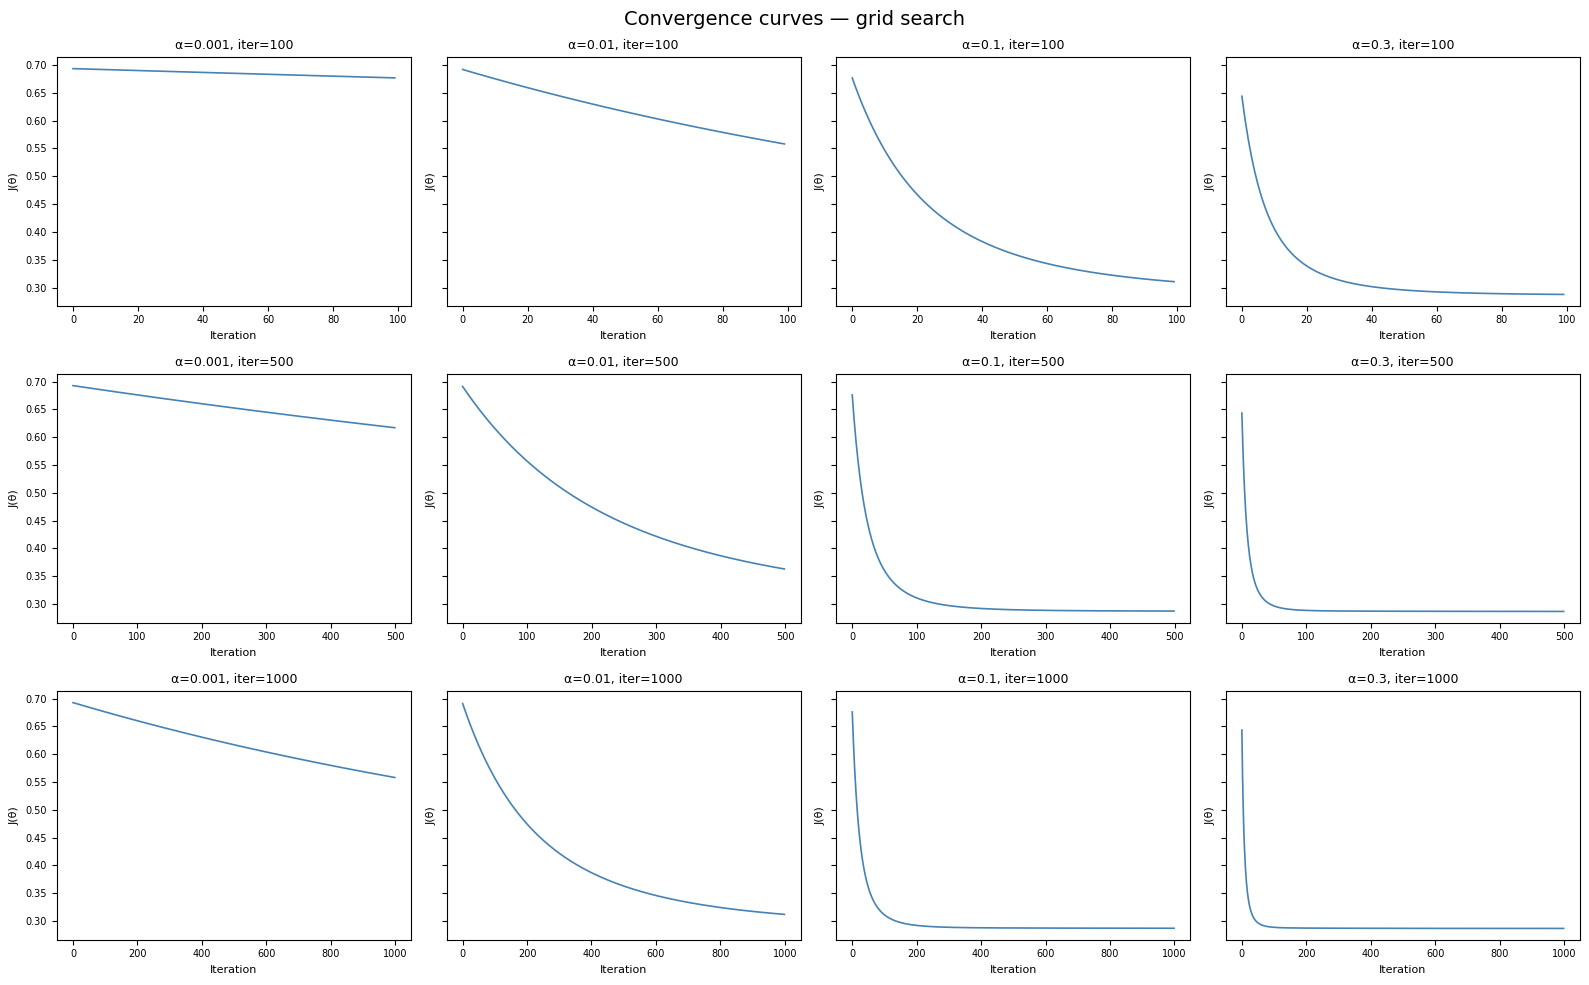

In [29]:
alphas     = [0.001, 0.01, 0.1, 0.3]
iterations = [100, 500, 1000]

fig, axes = plt.subplots(len(iterations), len(alphas), figsize=(16, 10), sharey="row")
fig.suptitle("Convergence curves — grid search", fontsize=14)

results = {}

for i, n_iter in enumerate(iterations):
    for j, alpha in enumerate(alphas):
        theta, cost_hist, _ = gradient_descent(X_train, y_train, alpha, n_iter)
        results[(alpha, n_iter)] = {"theta": theta, "final_cost": cost_hist[-1]}

        ax = axes[i][j]
        ax.plot(cost_hist, color="steelblue", linewidth=1.2)
        ax.set_title(f"α={alpha}, iter={n_iter}", fontsize=9)
        ax.set_xlabel("Iteration", fontsize=8)
        ax.set_ylabel("J(θ)", fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

### Final run

In [30]:
best_alpha = 0.3
best_iter  = 500

theta_final, cost_history, theta_history = gradient_descent(
    X_train, y_train, best_alpha, best_iter
)

print(f"Final cost: {cost_history[-1]:.6f}")
print(f"\nThetas:")
print(f"  bias:  {theta_final[0]:.4f}")
for name, t in zip(feature_cols, theta_final[1:]):
    print(f"  {name:<30} {t:.4f}")

Final cost: 0.286433

Thetas:
  bias:  -2.4558
  age                            -0.0269
  total_orders                   -0.4188
  total_spend_usd                0.1627
  avg_order_value_usd            -0.0857
  days_since_last_purchase       0.4550
  reviews_given                  -0.1790
  avg_review_score               -0.0544
  returns_made                   0.1091
  wishlist_items                 -0.0026
  newsletter_subscribed          0.0540


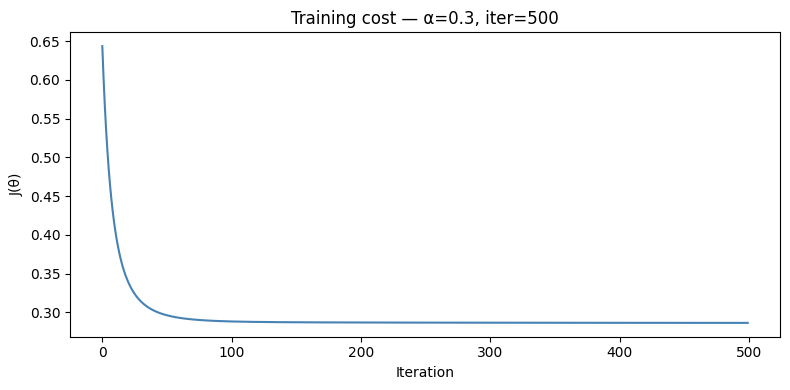

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="steelblue", linewidth=1.5)
plt.title(f"Training cost — α={best_alpha}, iter={best_iter}")
plt.xlabel("Iteration")
plt.ylabel("J(θ)")
plt.tight_layout()
plt.show()

## Evaluation

We convert probabilities to class predictions using a 0.5 threshold, then compute
accuracy, precision, recall, and F1 on the test set.

Unlike regression, MSE is not meaningful here — we care about whether the model
correctly separates churned from non-churned customers.

In [32]:
y_prob = sigmoid(X_test @ theta_final)
y_pred = (y_prob >= 0.5).astype(int)

tp = np.sum((y_pred == 1) & (y_test == 1))
tn = np.sum((y_pred == 0) & (y_test == 0))
fp = np.sum((y_pred == 1) & (y_test == 0))
fn = np.sum((y_pred == 0) & (y_test == 1))

accuracy  = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

Accuracy:  0.9175
Precision: 0.5000
Recall:    0.0152
F1:        0.0294


### Confusion matrix

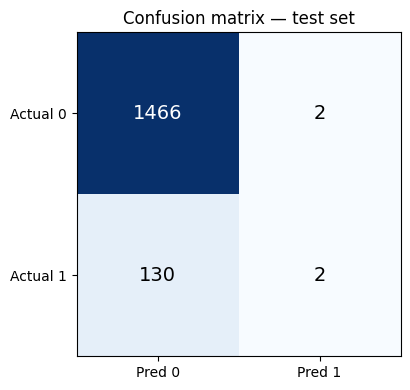

In [33]:
cm = np.array([[tn, fp],
               [fn, tp]])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pred 0", "Pred 1"])
ax.set_yticklabels(["Actual 0", "Actual 1"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_title("Confusion matrix — test set")
plt.tight_layout()
plt.show()

### Results

Accuracy looks high (~91%) but the model is nearly useless for the actual task: it predicts
almost everyone as "not churned" and only catches ~1.5% of real churners (recall = 0.015).

This is the **imbalanced dataset problem** — if ~92% of customers don't churn, predicting 0
every time already gives 92% accuracy. The model learned that bias instead of the actual pattern.

Fixing this is out of scope for now (solutions: lower the decision threshold, weight the loss
by class frequency, or resample the dataset), but it's important to recognize that
**accuracy alone is a misleading metric for imbalanced classification**.